Saved classified verbs to results\classified_processes_fixed.csv


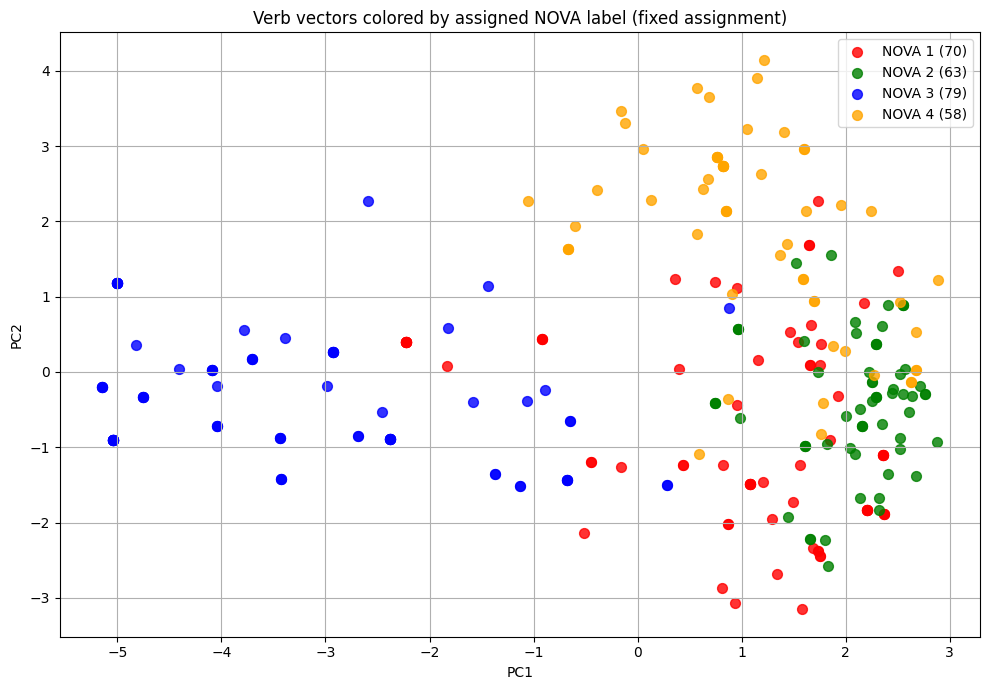

In [1]:
# ...existing code...
import pandas as pd
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
inp = Path("results/process_frequencies.csv")
out_csv = Path("results/classified_processes_fixed.csv")
df = pd.read_csv(inp, encoding="utf-8")
verbs = df['process'].dropna().astype(str).tolist()

# Load spaCy (make sure en_core_web_md or en_core_web_lg is installed)
nlp = spacy.load("en_core_web_md")

# Helper: lemmatize single-token verbs (keep multi-word as-is)
def lemma_token(token):
    doc = nlp(token)
    # if multi-token, lemmatize each and join
    return " ".join([t.lemma_.lower() for t in doc])

lemmas = [lemma_token(v) for v in verbs]
# Compute vectors (use token/phrase vector)
vecs = np.array([nlp(l).vector for l in lemmas])

# Seed anchor map (adjust anchors as you like)
nova_anchors = {
    "NOVA 1": ["wash", "clean", "peel", "slice", "cut", "chop", "shred", "grate", "place", "remove", "cool", "chill", "transfer"],
    "NOVA 2": ["press", "refine", "clarify", "extract"],
    "NOVA 3": ["cook", "boil", "simmer", "bake", "roast", "grill", "fry", "steam", "preheat", "heat", "cover", "sear"],
    "NOVA 4": ["emulsify", "reconstitute", "extrude", "hydrogenate", "preserve", "flavor", "additive", "mix (packet)", "instant"]
}

# Build anchor-centroid vectors (average of anchor lemma vectors that exist)
anchor_centroids = {}
for nova_label, anchors in nova_anchors.items():
    vec_list = []
    for a in anchors:
        la = lemma_token(a)
        v = nlp(la).vector
        # skip empty / zero vectors
        if np.linalg.norm(v) > 0.0:
            vec_list.append(v)
    if vec_list:
        anchor_centroids[nova_label] = np.mean(vec_list, axis=0)
    else:
        anchor_centroids[nova_label] = np.zeros_like(vecs[0])

# Assign NOVA per verb by cosine similarity to anchor centroids
anchor_labels = list(anchor_centroids.keys())
anchor_matrix = np.vstack([anchor_centroids[l] for l in anchor_labels])

sims = cosine_similarity(vecs, anchor_matrix)  # shape (n_verbs, n_anchors)
best_idx = sims.argmax(axis=1)
best_scores = sims.max(axis=1)
assigned = [anchor_labels[i] for i in best_idx]

# Build output DataFrame and merge frequencies
out = pd.DataFrame({
    "process": verbs,
    "lemma": lemmas,
    "nova_label": assigned,
    "confidence": best_scores
})
out = out.merge(df, left_on="process", right_on="process", how="left")

# Save CSV
out.to_csv(out_csv, index=False, encoding="utf-8")
print(f"Saved classified verbs to {out_csv}")

# Optional: PCA scatter with labels (for quick visual check)
pca = PCA(n_components=2)
coords = pca.fit_transform(vecs)
out['x'] = coords[:,0]; out['y'] = coords[:,1]

plt.figure(figsize=(10,7))
colors = {"NOVA 1":"red","NOVA 2":"green","NOVA 3":"blue","NOVA 4":"orange"}
for lbl in anchor_labels:
    sub = out[out['nova_label']==lbl]
    plt.scatter(sub['x'], sub['y'], c=colors[lbl], label=f"{lbl} ({len(sub)})", s=50, alpha=0.8)
# annotate a few low/high confidence examples if needed
plt.legend()
plt.title("Verb vectors colored by assigned NOVA label (fixed assignment)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()
# ...existing code...

In [4]:
import pandas as pd
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

IN = Path("results/process_frequencies.csv")
OUT = Path("results/classified_processes_fixed.csv")
AMB = Path("results/ambiguous_verbs.csv")

df = pd.read_csv(IN, encoding="utf-8")
verbs = df['process'].dropna().astype(str).tolist()

# load best spaCy model available
try:
    nlp = spacy.load("en_core_web_lg")
except Exception:
    nlp = spacy.load("en_core_web_md")

# lemmatize and keep POS info
def lemma_and_pos(token_text):
    doc = nlp(token_text)
    lemmas = [t.lemma_.lower() for t in doc if not t.is_punct and not t.is_space]
    pos_tags = [t.pos_ for t in doc]
    return " ".join(lemmas), pos_tags

lemmas = []
pos_info = []
for v in verbs:
    l, p = lemma_and_pos(v)
    lemmas.append(l if l else v.lower())
    pos_info.append(p)

# compute vectors (use phrase vector)
vecs = np.array([nlp(l).vector for l in lemmas])

# seed anchors (expand these if you can)
nova_anchors = {
    "NOVA 1": ["wash", "clean", "peel", "slice", "cut", "chop", "shred", "grate", "place", "remove", "cool", "chill", "transfer"],
    "NOVA 2": ["press", "refine", "clarify", "extract"],
    "NOVA 3": ["cook", "boil", "simmer", "bake", "roast", "grill", "fry", "steam", "preheat", "heat", "cover", "sear"],
    "NOVA 4": ["emulsify", "reconstitute", "extrude", "hydrogenate", "preserve", "flavor", "additive"]
}

# build anchor centroids
anchor_centroids = {}
for label, anchors in nova_anchors.items():
    vecs_a = []
    for a in anchors:
        la, _ = lemma_and_pos(a)
        v = nlp(la).vector
        if np.linalg.norm(v) > 0:
            vecs_a.append(v)
    anchor_centroids[label] = np.mean(vecs_a, axis=0) if vecs_a else np.zeros_like(vecs[0])

anchor_labels = list(anchor_centroids.keys())
anchor_matrix = np.vstack([anchor_centroids[l] for l in anchor_labels])

# similarities and assignment
sims = cosine_similarity(vecs, anchor_matrix)  # (n_verbs, n_anchors)
top1_idx = sims.argmax(axis=1)
top1_scores = sims.max(axis=1)
# compute second best to detect ambiguity
top2_scores = np.partition(sims, -2, axis=1)[:, -2]

assigned = [anchor_labels[i] for i in top1_idx]
confidence = top1_scores
score_gap = top1_scores - top2_scores

# thresholds
CONF_THRESH = 0.45
GAP_THRESH = 0.05

out = pd.DataFrame({
    "process": verbs,
    "lemma": lemmas,
    "pos": [";".join(p) for p in pos_info],
    "nova_label": assigned,
    "confidence": confidence,
    "score_gap": score_gap
})
out = out.merge(df, left_on="process", right_on="process", how="left")
out.to_csv(OUT, index=False, encoding="utf-8")

# ambiguous list for manual review
ambiguous = out[(out['confidence'] < CONF_THRESH) | (out['score_gap'] < GAP_THRESH)]
ambiguous.sort_values(['confidence','score_gap'], inplace=True)
ambiguous.to_csv(AMB, index=False, encoding="utf-8")

print(f"Saved {len(out)} classified verbs to {OUT}")
print(f"Saved {len(ambiguous)} ambiguous verbs to {AMB} (review & correct)")

# tip: after you manually edit ambiguous_verbs.csv (add a column nova_label_correct),
# you can load it and override labels in OUT programmatically.

Saved 270 classified verbs to results\classified_processes_fixed.csv
Saved 168 ambiguous verbs to results\ambiguous_verbs.csv (review & correct)


C:\Users\hvish\AppData\Local\Temp\ipykernel_28060\2827016653.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ambiguous.sort_values(['confidence','score_gap'], inplace=True)


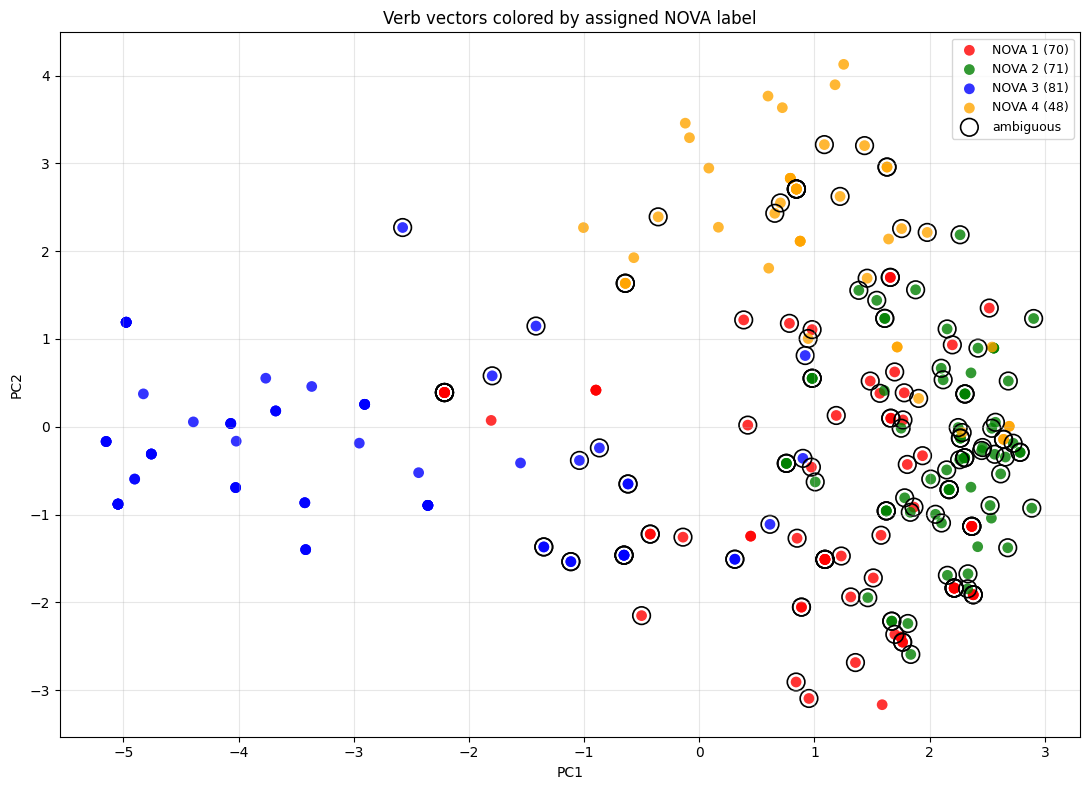

In [5]:
import pandas as pd
import spacy
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

# files
OUT = Path("results/classified_processes_fixed.csv")
AMB = Path("results/ambiguous_verbs.csv")
IMG = Path("results/nova_scatter.png")

# load results
df = pd.read_csv(OUT, encoding="utf-8")
amb = pd.read_csv(AMB, encoding="utf-8") if AMB.exists() else pd.DataFrame(columns=["process"])

# load spaCy (try large, fall back to md)
try:
    nlp = spacy.load("en_core_web_lg")
except Exception:
    nlp = spacy.load("en_core_web_md")

# prepare lemma column and vectors
lemmas = df['lemma'].fillna(df['process']).astype(str).tolist()
vecs = np.vstack([nlp(l).vector for l in lemmas])

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)
df['x'], df['y'] = coords[:,0], coords[:,1]

# plotting
colors = {"NOVA 1":"red","NOVA 2":"green","NOVA 3":"blue","NOVA 4":"orange"}
plt.figure(figsize=(11,8))
for lbl, col in colors.items():
    sub = df[df['nova_label']==lbl]
    plt.scatter(sub['x'], sub['y'], c=col, label=f"{lbl} ({len(sub)})", s=60, alpha=0.8, edgecolors='none')

# highlight ambiguous verbs (if any)
if not amb.empty:
    amb_set = set(amb['process'].astype(str).tolist())
    mask = df['process'].isin(amb_set)
    plt.scatter(df.loc[mask,'x'], df.loc[mask,'y'], facecolors='none', edgecolors='k', s=160, linewidths=1.2, label='ambiguous')

plt.title("Verb vectors colored by assigned NOVA label")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG, dpi=200)
plt.show()
